/var/folders/9z/9fdpt4_148s8zzl9h0tr9dgw0000gn/T/ipykernel_10576/513866433.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, 


🔍 Worst 10 predictions by mean MSE:


,S_index,mean_mse,var_mse,max_mean_error,max_var_error
7,7,28.159354,0.020017,9.160180,0.277207
24,24,28.135063,0.020017,9.138416,0.277207
10,10,27.928615,0.020017,9.096417,0.277206
18,18,27.849985,0.020017,9.071490,0.277205
9,9,27.828861,0.020017,9.064656,0.277205
20,20,27.735197,0.020016,9.024912,0.277202
23,23,27.625661,0.020011,8.605568,0.277183
17,17,27.565276,0.020016,8.974173,0.277197
25,25,27.563559,0.020015,8.931559,0.277195
3,3,27.551272,0.020015,8.896602,0.277190



📊 Overall stats:
         S_index   mean_mse    var_mse  max_mean_error  max_var_error
count  30.000000  30.000000  30.000000       30.000000      30.000000
mean   14.500000  27.221634   0.020014        8.730611       0.277184
std     8.803408   0.468680   0.000003        0.238271       0.000026
min     0.000000  26.635576   0.020001        8.431908       0.277091
25%     7.250000  26.806485   0.020013        8.521520       0.277180
50%    14.500000  27.087592   0.020015        8.648966       0.277190
75%    21.750000  27.564847   0.020016        8.922820       0.277200
max    29.000000  28.159354   0.020017        9.160180       0.277207


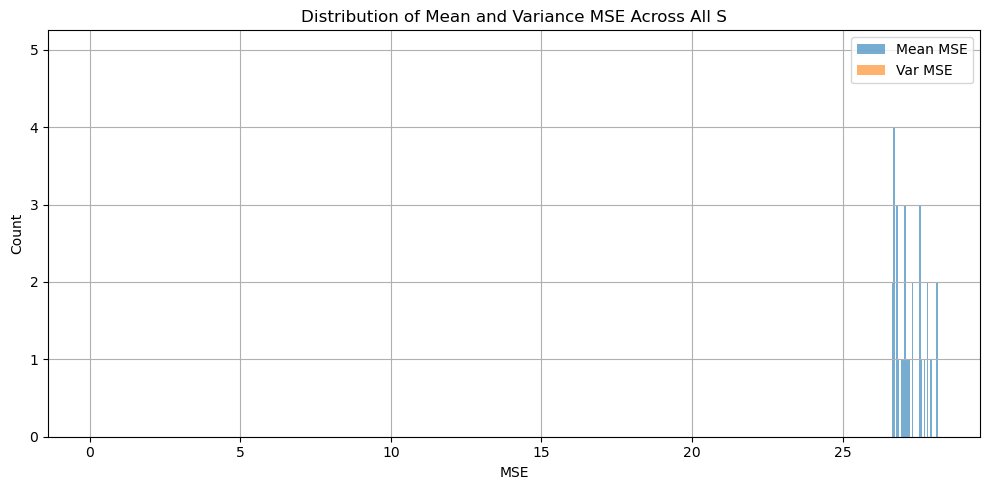

In [3]:
import torch
import numpy as np
from models.gaussian_forward import GaussianForwardModel
from utils.load_data import load_distributional_dataset
from config import DISTRIBUTIONAL_DATA_PATH

from tqdm import tqdm
import pandas as pd

# === Load model ===
trial = 14
model_path = f"checkpoints/gaussian/gaussian_trial_{trial}/gaussian_ckpt_{trial}.pt"
hidden_dims = [128, 64, 32]
S_DIM, P_DIM = 4, 9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GaussianForwardModel(S_DIM, P_DIM, hidden_dims=hidden_dims).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# === Load empirical dataset ===
empirical_data = load_distributional_dataset(DISTRIBUTIONAL_DATA_PATH)
S_keys = list(empirical_data.keys())

# === Run diagnostics across all S ===
results = []

for idx, S_key in tqdm(enumerate(S_keys), total=len(S_keys)):
    S = np.array(S_key)
    P_empirical = np.array(empirical_data[S_key])  # shape (num_samples, 9)

    # Empirical stats
    emp_mean = np.mean(P_empirical, axis=0)
    emp_var = np.var(P_empirical, axis=0)

    # Model prediction
    S_tensor = torch.tensor(S, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_mean, pred_var = model(S_tensor)
    pred_mean = pred_mean.cpu().numpy().flatten()
    pred_var = pred_var.cpu().numpy().flatten()

    # === Denormalize predicted mean and variance ===
    P_mean = np.load("data/P_mean.npy")
    P_std = np.load("data/P_std.npy")

    pred_mean = pred_mean * P_std + P_mean
    pred_var = pred_var * (P_std ** 2)  # because Var[aX + b] = a^2 Var[X]

    # === Compute diagnostics ===
    mean_mse = np.mean((emp_mean - pred_mean) ** 2)
    var_mse = np.mean((emp_var - pred_var) ** 2)

    results.append({
        'S_index': idx,
        'mean_mse': mean_mse,
        'var_mse': var_mse,
        'max_mean_error': np.max(np.abs(emp_mean - pred_mean)),
        'max_var_error': np.max(np.abs(emp_var - pred_var)),
    })

# === Convert to DataFrame and analyze ===
df = pd.DataFrame(results)
df_sorted = df.sort_values("mean_mse", ascending=False)

print("\n🔍 Worst 10 predictions by mean MSE:")
display(df_sorted.head(10))

print("\n📊 Overall stats:")
print(df.describe())

# Optional: plot MSE distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(df["mean_mse"], bins=30, alpha=0.6, label="Mean MSE")
plt.hist(df["var_mse"], bins=30, alpha=0.6, label="Var MSE")
plt.xlabel("MSE")
plt.ylabel("Count")
plt.title("Distribution of Mean and Variance MSE Across All S")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
# Peek at one example from your distributional dataset
example_S = list(empirical_data.keys())[0]
print("Empirical P samples for S[0]:\n", np.array(empirical_data[example_S]))


Empirical P samples for S[0]:
 [[0.38200509 0.12474964 0.1555389  0.40917256 0.15853776 0.62246901
  0.31298376 0.30602789 0.2237437 ]
 [0.37282937 0.12585973 0.15480888 0.42863043 0.16248018 0.61723095
  0.32102285 0.30166249 0.22488055]
 [0.37072262 0.12593017 0.15466028 0.43276892 0.16387652 0.61073034
  0.32487369 0.29943594 0.22797433]
 [0.38237548 0.12488563 0.15561396 0.41617594 0.16056379 0.61929136
  0.31648363 0.30400216 0.22410903]
 [0.37084343 0.12516602 0.15373857 0.42147651 0.16101806 0.62325481
  0.31958624 0.2984966  0.22223542]
 [0.39350685 0.12375437 0.15819846 0.40819182 0.15854574 0.62126653
  0.3114307  0.31081017 0.22121748]
 [0.36443205 0.12355618 0.15242502 0.42972922 0.16271852 0.62217198
  0.32347304 0.29670249 0.22085085]
 [0.37982928 0.12559806 0.15603784 0.42449354 0.1622258  0.61842702
  0.32082524 0.30337416 0.22446799]
 [0.37927066 0.12422092 0.155122   0.42271573 0.16223585 0.61503665
  0.32092917 0.30265173 0.22289703]
 [0.38002024 0.12265617 0.1556568